# 4. Analysis — Aggregate Results & Visualize

Load results from each experiment stage and produce comparison plots.

> Set `STAGE_TO_ANALYZE` to match the stage you want to visualize.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({'font.size': 18})
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 16
# ============================================================
# Cell 1 — Configuration
# ============================================================
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

sns.set_theme(style='whitegrid', font_scale=1.1)

# Which stage to analyze: 'feature' | 'model' | 'instrument'
STAGE_TO_ANALYZE = 'instrument'

OUTPUT_DIR = Path('./outputs')

In [7]:
# ============================================================
# Cell 2 — Load Results
# ============================================================
json_file = OUTPUT_DIR / f'results_stage_{STAGE_TO_ANALYZE}.json'
pkl_file = OUTPUT_DIR / f'results_stage_{STAGE_TO_ANALYZE}_full.pkl'

with open(json_file, 'r') as f:
    results_json = json.load(f)

rdf = pd.DataFrame(results_json)

# ---- Display columns: mir_eval metrics as primary ----
display_cols = ['model', 'instrument', 'feature',
                'best_val_acc', 'mir_root', 'mir_majmin', 'mir_mirex',
                'overseg', 'underseg', 'seg']
# Only show columns that exist in the data
display_cols = [c for c in display_cols if c in rdf.columns]
display(rdf[display_cols])

# Load full history if available
full_results = None
if pkl_file.exists():
    with open(pkl_file, 'rb') as f:
        full_results = pickle.load(f)
    print(f'Full history loaded ({len(full_results)} experiments)')

,model,instrument,feature,best_val_acc,mir_root,mir_majmin,mir_mirex,overseg,underseg,seg
0,lstm,bass,chromagram,0.435661,0.475656,0.460918,0.460918,0.986106,0.884981,0.884721
1,lstm,guitar,chromagram,0.491942,0.484380,0.476880,0.476880,0.982052,0.896892,0.896892
2,lstm,guitar_piano,chromagram,0.510905,0.506807,0.498476,0.498476,0.988606,0.884637,0.883942
3,lstm,guitar_piano_bass,chromagram,0.637308,0.693861,0.681567,0.681567,0.989353,0.896326,0.895171
4,lstm,no_vocals,chromagram,0.656874,0.646856,0.632546,0.632546,0.987842,0.842282,0.842282
5,lstm,piano,chromagram,0.488095,0.556284,0.545584,0.545584,0.989922,0.883577,0.883577
6,lstm,raw_audio,chromagram,0.613618,0.584635,0.578865,0.578865,0.985631,0.880646,0.880646
7,lstm,vocals,chromagram,0.263286,0.267741,0.258899,0.258899,0.971741,0.737790,0.737790


Full history loaded (8 experiments)


/var/folders/w8/37n9094n1x7_cgq0g3nt7vsr0000gn/T/ipykernel_45493/1826429322.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rdf, x=x_col, y=metric_col, ax=ax,


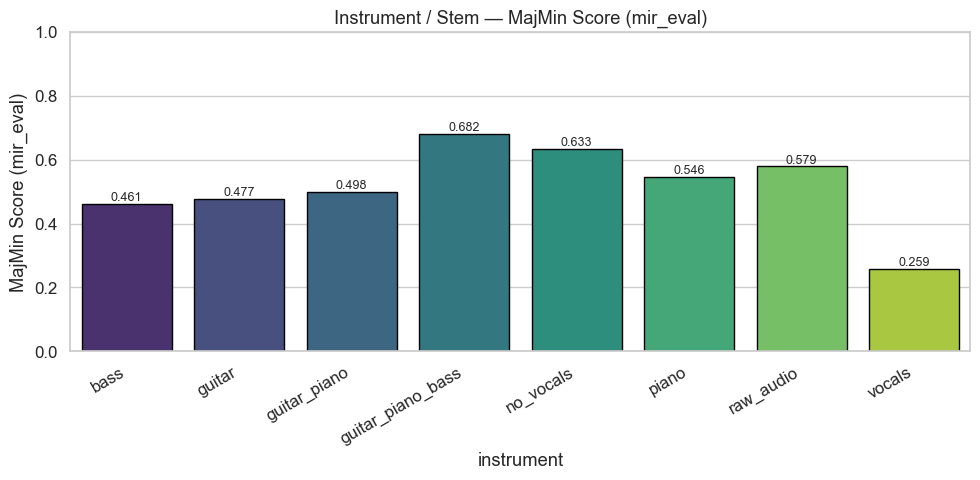

In [8]:
# ============================================================
# Cell 3 — Bar Chart: mir_eval MajMin Score (primary metric)
# ============================================================
# Determine which metric column to plot
metric_col = 'mir_majmin' if 'mir_majmin' in rdf.columns else 'best_val_acc'
metric_label = 'MajMin Score (mir_eval)' if metric_col == 'mir_majmin' else 'Best Validation Accuracy'

fig, ax = plt.subplots(figsize=(10, 5))

if STAGE_TO_ANALYZE == 'feature':
    x_col, title = 'feature', f'Feature Extraction — {metric_label}'
elif STAGE_TO_ANALYZE == 'model':
    x_col, title = 'model', f'Model Architecture — {metric_label}'
elif STAGE_TO_ANALYZE == 'instrument':
    x_col, title = 'instrument', f'Instrument / Stem — {metric_label}'

sns.barplot(data=rdf, x=x_col, y=metric_col, ax=ax,
            palette='viridis', edgecolor='black')
ax.set_title(title)
ax.set_ylabel(metric_label)
ax.set_ylim(0, 1)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'bar_{STAGE_TO_ANALYZE}.png', dpi=150)
plt.show()

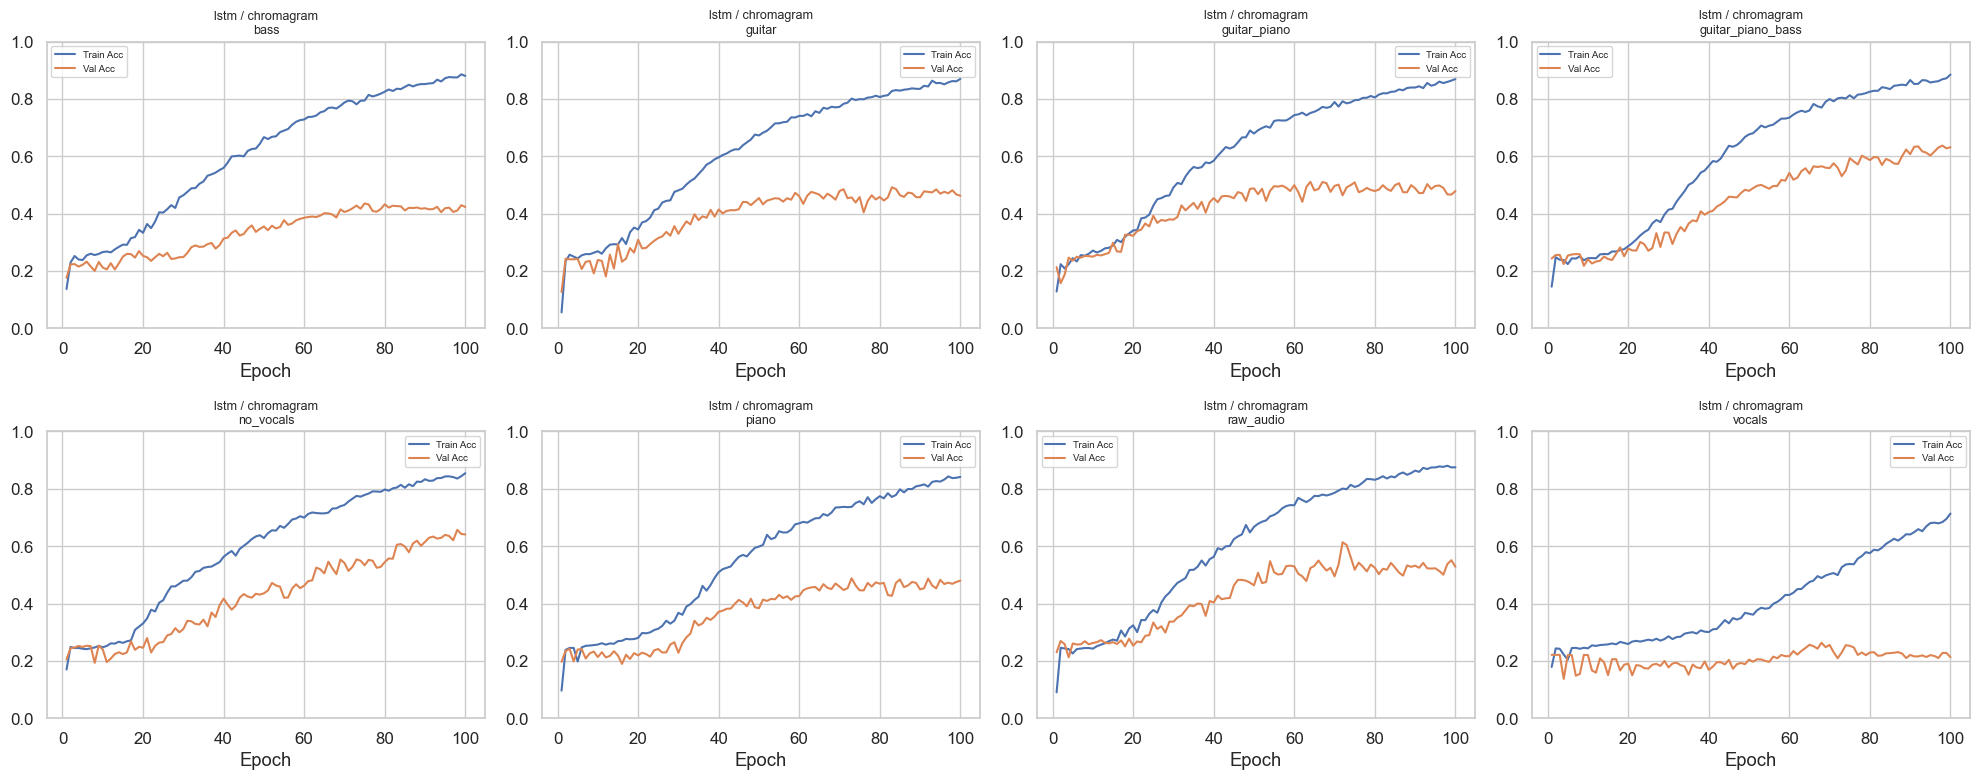

In [13]:
# ============================================================
# Cell 4 — Training Curves
# ============================================================
if full_results:
    import math
    n_exp = len(full_results)
    
    # Ubah jumlah kolom menjadi 4
    n_cols = 4
    n_rows = math.ceil(n_exp / n_cols)
    
    # Sesuaikan figsize agar lebih lebar (misal: lebar 20, tinggi menyesuaikan baris)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows), squeeze=False)

    for i, r in enumerate(full_results):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row][col]
        h = r['history']
        epochs = range(1, len(h['train_loss'])+1)
        ax.plot(epochs, h['train_acc'], label='Train Acc')
        ax.plot(epochs, h['val_acc'], label='Val Acc')
        ax.set_title(f"{r['model']} / {r.get('feature','')}\n{r.get('instrument','')}", fontsize=9)
        ax.set_xlabel('Epoch')
        ax.set_ylim(0, 1)
        ax.legend(fontsize=7)

    # (Opsional) Sembunyikan axis yang kosong jika jumlah eksperimen kurang dari kelipatan 4
    for j in range(i + 1, n_rows * n_cols):
        row = j // n_cols
        col = j % n_cols
        axes[row][col].axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'curves_{STAGE_TO_ANALYZE}.png', dpi=150)
    plt.show()
else:
    print('Full history not available (pkl file missing).')

In [10]:
# ============================================================
# Cell 5 — Cross-Stage Summary (run after all 3 stages)
# ============================================================
all_stages = []
for stage in ['feature', 'model', 'instrument']:
    p = OUTPUT_DIR / f'results_stage_{stage}.json'
    if p.exists():
        with open(p) as f:
            data = json.load(f)
        for row in data:
            row['stage'] = stage
        all_stages.extend(data)

if all_stages:
    summary = pd.DataFrame(all_stages)
    print('=== Cross-Stage Summary ===')
    # Use mir_majmin as primary sort metric if available
    sort_col = 'mir_majmin' if 'mir_majmin' in summary.columns else 'best_val_acc'
    show_cols = ['stage', 'model', 'instrument', 'feature',
                 'best_val_acc', 'mir_root', 'mir_majmin', 'mir_mirex',
                 'overseg', 'underseg', 'seg']
    show_cols = [c for c in show_cols if c in summary.columns]
    display(summary[show_cols].sort_values(sort_col, ascending=False))
else:
    print('No results found yet. Run modeling stages first.')

=== Cross-Stage Summary ===


,stage,model,instrument,feature,best_val_acc,mir_root,mir_majmin,mir_mirex,overseg,underseg,seg
11,instrument,lstm,guitar_piano_bass,chromagram,0.637308,0.693861,0.681567,0.681567,0.989353,0.896326,0.895171
12,instrument,lstm,no_vocals,chromagram,0.656874,0.646856,0.632546,0.632546,0.987842,0.842282,0.842282
5,model,lstm,raw_audio,chromagram,0.629941,0.638951,0.610694,0.610694,0.985473,0.907168,0.907168
6,model,bilstm,raw_audio,chromagram,0.576859,0.610659,0.593205,0.593205,0.988125,0.864831,0.864641
1,feature,lstm,raw_audio,chromagram,0.595908,0.595607,0.579189,0.579189,0.982472,0.934555,0.934555
14,instrument,lstm,raw_audio,chromagram,0.613618,0.584635,0.578865,0.578865,0.985631,0.880646,0.880646
7,model,transformer,raw_audio,chromagram,0.555074,0.597774,0.575943,0.575943,0.990335,0.842632,0.842632
13,instrument,lstm,piano,chromagram,0.488095,0.556284,0.545584,0.545584,0.989922,0.883577,0.883577
10,instrument,lstm,guitar_piano,chromagram,0.510905,0.506807,0.498476,0.498476,0.988606,0.884637,0.883942
4,model,gru,raw_audio,chromagram,0.519053,0.505722,0.487730,0.487730,0.979822,0.936546,0.936546
